[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_4_2_MLR_Ames_Part2_Revised.ipynb)

# MLR Predicting Housing Prices in Ames Iowa: Part 2
## Forward and Backward Selection with Cross-Validation

**Summary:** To Do

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data source
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'

# Loading the dataframe
df_raw = pd.read_csv(url, sep='\t')

# Initial cleaning: remove extreme outliers per the author's recommendation, large houses sold for little money due to inheritance
df = df_raw.loc[df_raw['Gr Liv Area'] < 4000, :].copy()

# Fix Garge Year Built in the Future
df.loc[df['Garage Yr Blt'] > 2010, 'Garage Yr Blt'] = 200

# helper functions
def safe_drop(df: pd.DataFrame, drop_list: list[str]) -> pd.DataFrame:
  """
  Safely drops columns from a Pandas DataFrame if they exist.

  Args:
    df (pd.DataFrame): The input DataFrame.
    drop_list (list[str]): A list of column names to attempt to drop.

  Returns:
    pd.DataFrame: The DataFrame with specified columns dropped (if they existed).
  """
  # Filter drop_list to only include columns that exist in the DataFrame
  existing_cols_to_drop = [col for col in drop_list if col in df.columns]

  # Drop the columns if there are any to drop
  if existing_cols_to_drop:
    df = df.drop(existing_cols_to_drop, axis=1)
  return df



#################################################
# compressed cleaning code from Part 1
#################################################

print(df.shape)

if 'garage_attached' not in df.columns:
  df['garage_attached'] = np.where(df['Garage Type'] == 'Attchd', 1, 0)
if 'garage_unfinished' not in df.columns:
  df['garage_unfinished'] = np.where(df['Garage Finish'] != 'Unf', 1, 0)

drop_list = ['Order',
            'PID',
            'Pool QC',
            'Pool Area',
            'Misc Feature',
            'Misc Val',
            'Alley',
            'Fence',
            'Mas Vnr Type',
            'Bsmt Qual',
            'Bsmt Cond',
            'Bsmt Exposure',
            'BsmtFin Type 1',
            'BsmtFin Type 2',
            'Fireplace Qu',
            'Neighborhood',
            'MS Subclass',
            'Mo Sold',
            'Kitchen Qual',
            'Exter QualHeating QC',
            'Garage Qual',
            'Garage Cond',
            'Garage Type',
            'Garage Finish',
            'Street',
            'Land Contour',
            'Utilities',
            'Land Slope',
            'Condition 1',
            'Condition 2',
            'Roof Matl',
            'Exter Cond',
            'Heating',
            'Central Air',
            'Electrical',
            'Functional',
            'Paved Drive',
            'Sale Type']

df = safe_drop(df, drop_list)

for col in df.select_dtypes(include=['object']).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.50:
    top_value = (df[col].value_counts(normalize=True, dropna=False).index[0])
    df[col + '_' + top_value] = np.where(df[col] == top_value, 1, 0)
    df = safe_drop(df, [col])

df.loc[~df['Foundation'].isin(['PConc', 'CBlock']), 'Foundation'] = 'Other'

df = safe_drop(df, ['Exterior 1st', 'Exterior 2nd'])

for col in df.select_dtypes('object').columns:
  df[col] = df[col].astype('category')

for col in df.columns:
  if df[col].value_counts().shape[0] == 2:
    df[col] = df[col].astype('bool')

for col in df.select_dtypes(include=np.number).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.90:
    df = safe_drop(df, [col])

for col in df.select_dtypes(include=np.number).columns:
  if df[col].value_counts(normalize=True, dropna=False).max() > 0.80:
    if len(df[col].unique()) > 2:
      df[col] = np.where(df[col] > 0, 1, 0)
    df[col] = df[col].astype('boolean')

df = safe_drop(df, ['Mas Vnr Area'])

num_cols_with_na = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()
for col in num_cols_with_na:
    df[col] = df[col].fillna(df[col].median())

print(df.shape)

(2925, 82)
(2925, 40)


In [2]:
def plot_histogram_boxplot_combos(df, features):
  '''
  takes: a dataframe and a list of column names
  return: None
  '''
  # Number of features
  n_features = len(features)

  # Set up the matplotlib figure
  fig, axes = plt.subplots(n_features, 2, figsize=(10, n_features*3))

  for i, col in enumerate(features):
      # Histogram for normality
      sns.histplot(df[col], ax=axes[i, 0], kde=True)
      axes[i, 0].set_title(f'Histogram: {col}')

      # Boxplot for outliers
      sns.boxplot(x=df[col], ax=axes[i, 1])
      axes[i, 1].set_title(f'Boxplot: {col}')

  plt.tight_layout()
  plt.show()

# Redefine numeric_features to reflect the current columns in df
numeric_features = list(df.select_dtypes(include=np.number).columns.values)

if False: # swtich to turn on plots
  plot_histogram_boxplot_combos(df, df.select_dtypes(np.number).columns)

## One-Hot Encoding
Machine learning models require numeric input. We use `pd.get_dummies` to turn our text categories into columns of 1s and 0s.

**Question:** Why do we use `drop_first=True`? (Search for "The Dummy Variable Trap" if you are unsure).

In [3]:
# Identify multi-level categories
df = pd.get_dummies(df, columns=df.select_dtypes(include='category').columns, drop_first=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2925 entries, 0 to 2929
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   MS SubClass            2925 non-null   int64  
 1   Lot Frontage           2925 non-null   float64
 2   Lot Area               2925 non-null   int64  
 3   Overall Qual           2925 non-null   int64  
 4   Overall Cond           2925 non-null   int64  
 5   Year Built             2925 non-null   int64  
 6   Year Remod/Add         2925 non-null   int64  
 7   BsmtFin SF 1           2925 non-null   float64
 8   BsmtFin SF 2           2925 non-null   boolean
 9   Bsmt Unf SF            2925 non-null   float64
 10  Total Bsmt SF          2925 non-null   float64
 11  1st Flr SF             2925 non-null   int64  
 12  2nd Flr SF             2925 non-null   int64  
 13  Gr Liv Area            2925 non-null   int64  
 14  Bsmt Full Bath         2925 non-null   float64
 15  Full Bath

## MLR with Forward and Backward Selection


### Selection and Evaluation Function

In [4]:
from typing import Dict, Any
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split


def perform_feature_selection_and_evaluation(
    X: pd.DataFrame,
    y: pd.Series,
    selection_direction: str = 'forward',
    cv_folds: int = 5
) -> Dict[str, Any]:
    """
    Performs feature selection and evaluates a Linear Regression model using cross-validation.
    Uses a Pipeline to prevent data leakage during cross-validation.

    Args:
        X (pd.DataFrame): Independent variables.
        y (pd.Series): Dependent variable.
        selection_direction (str): 'forward' or 'backward' for SequentialFeatureSelector.
        cv_folds (int): Number of cross-validation folds.

    Returns:
        dict: A dictionary containing the fitted pipeline, selected feature names, and CV metrics.
    """

    # 1. Build a Pipeline to prevent Data Leakage
    # Everything inside the pipeline is strictly applied to the training folds during CV.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('selector', SequentialFeatureSelector(
            LinearRegression(),
            n_features_to_select='auto',
            direction=selection_direction,
            cv=cv_folds
        )),
        ('model', LinearRegression())
    ])

    # 2. Perform Cross-Validation efficiently in one pass
    # Using built-in string aliases for standard metrics
    scoring_metrics = ['r2', 'neg_mean_squared_error']
    cv_results = cross_validate(pipeline, X, y, cv=cv_folds, scoring=scoring_metrics)

    # Extract metrics (negating MSE to make it positive)
    # It's initially negative becuase scikit-learn follows a "Higher is Better" convention for all its scoring metrics.
    cv_r2 = cv_results['test_r2']
    cv_mse = -cv_results['test_neg_mean_squared_error']

    print(f"Cross-validated R-squared (mean \u00b1 std): {cv_r2.mean():.4f} \u00b1 {cv_r2.std():.4f}")
    print(f"Cross-validated Mean Squared Error (mean \u00b1 std): {cv_mse.mean():.4f} \u00b1 {cv_mse.std():.4f}\n")

    # 3. Fit the pipeline on the ENTIRE dataset passed to this function
    # (typically either the training or the test set, not the complete dataset, see below)
    # to get final features and coefficients
    pipeline.fit(X, y)

    # Extract the fitted steps from the pipeline
    final_selector = pipeline.named_steps['selector']
    final_model = pipeline.named_steps['model']

    # Identify selected features
    selected_mask = final_selector.get_support()
    selected_feature_names = X.columns[selected_mask].tolist()

    # 4. Print results
    print(f"Intercept: {final_model.intercept_:.4f}\n")
    print(f"Standardized Coefficients (Betas) from full data fit (using {selection_direction} selection):")

    if selected_feature_names:
        max_feature_len = max(len(feature) for feature in selected_feature_names)
        for name, coef in zip(selected_feature_names, final_model.coef_):
            print(f"\t{name.ljust(max_feature_len)}:\t {coef:>7.2f}")
    else:
        print("\tNo features selected.")

    # 5. Return a useful dictionary instead of `None`
    return {
        'model_pipeline': pipeline,
        'selected_features': selected_feature_names,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_mse_mean': cv_mse.mean(),
        'cv_mse_std': cv_mse.std()
    }

### Forward Selection with Cross Validation

In [5]:
def run_modeling_workflow(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.20,
    random_state: int = 42,
    selection_direction: str = 'forward',
    cv_folds: int = 5,
    plot_residuals: bool = True
) -> Dict[str, Any]:
  """
  Encapsulates the entire MLR modeling workflow including train-test split,
  feature selection, model training, evaluation, and optional residual plotting.

  Args:
    X (pd.DataFrame): Independent variables (or Features).
    y (pd.Series): Dependent variable (or outcome).
    test_size (float): The proportion of the dataset to include in the test split.
    random_state (int): Seed used by the random number generator for reproducibility.
    selection_direction (str): 'forward' or 'backward' for SequentialFeatureSelector.
    cv_folds (int): Number of cross-validation folds.
    plot_residuals (bool): Whether to plot residuals.

  Returns:
    dict: A dictionary containing final test metrics, selected features,
          the fitted pipeline, residuals, and test predictions.
  """

  # 1. TRAIN-TEST SPLIT
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=random_state
  )

  # 2. CROSS-VALIDATION & FEATURE SELECTION
  print("--- Running Cross-Validation on Training Data ---")
  results = perform_feature_selection_and_evaluation(
      X=X_train,
      y=y_train,
      selection_direction=selection_direction,
      cv_folds=cv_folds
  )

  final_model = results['model_pipeline']
  selected_features = results['selected_features']

  # 3. FINAL EVALUATION ON UNSEEN TEST DATA
  print("\n--- Running Final Evaluation on Unseen Test Data ---")
  test_predictions = final_model.predict(X_test)

  final_r2 = r2_score(y_test, test_predictions)
  final_mse = mean_squared_error(y_test, test_predictions)

  print(f"Final Test R-squared: {final_r2:.4f}")
  print(f"Final Test MSE:       {final_mse:.4f}")

  # 4. RESIDUAL ANALYSIS
  residuals = y_test - test_predictions

  if plot_residuals:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, kde=True)
    plt.title('Histogram of Residuals')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=test_predictions, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Residuals vs. Predicted Values')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')

    plt.tight_layout()
    plt.show()

  return {
      'final_r2': final_r2,
      'final_mse': final_mse,
      'selected_features': selected_features,
      'model_pipeline': final_model,
      'residuals': residuals,
      'test_predictions': test_predictions
  }

# Example of how to call the function:
# modeling_results = run_modeling_workflow(X, y, test_size=0.2, random_state=42)


### Define Features and Outcomes

--- Running Cross-Validation on Training Data ---
Cross-validated R-squared (mean ± std): 0.8643 ± 0.0118
Cross-validated Mean Squared Error (mean ± std): 805475368.1368 ± 100599040.1985

Intercept: 179791.9282

Standardized Coefficients (Betas) from full data fit (using forward selection):
	MS SubClass     :	 -2461.35
	Lot Frontage    :	 1952.59
	Lot Area        :	 5095.11
	Overall Qual    :	 22098.62
	Overall Cond    :	 5982.59
	Year Built      :	 11464.99
	Year Remod/Add  :	 1809.95
	BsmtFin SF 1    :	 10530.08
	Total Bsmt SF   :	 9159.63
	Gr Liv Area     :	 31536.25
	Bedroom AbvGr   :	 -7255.05
	Garage Area     :	 5680.72
	Wood Deck SF    :	 1869.25
	Yr Sold         :	 -2308.98
	garage_attached :	 -3976.31
	Bldg Type_1Fam  :	 3450.18
	Roof Style_Gable:	 -3469.58
	Exter Qual_TA   :	 -3291.34
	Heating QC_Ex   :	 1978.23
	Foundation_PConc:	 2781.54

--- Running Final Evaluation on Unseen Test Data ---
Final Test R-squared: 0.8824
Final Test MSE:       835793864.2740


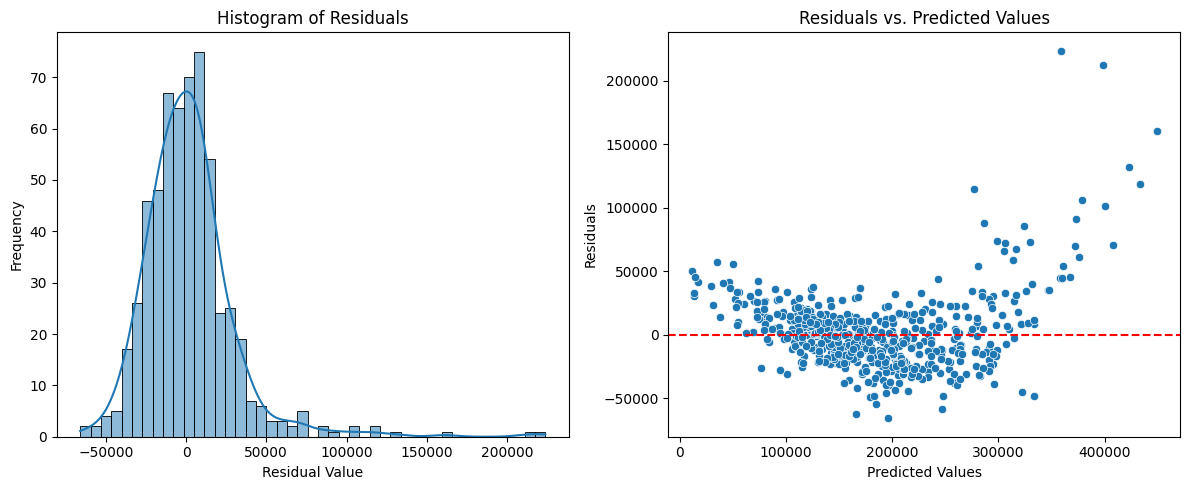

In [6]:
# define features and outcome
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

modeling_results = run_modeling_workflow(X, y, test_size=0.2, random_state=42)

## Interpreting Results

**Issue 1: Why is the coefficient for Bedroom AbvGr negative (-7255.05)?**

One way to interpret the coefficients is that they reflect the effect of that single feature changing while all of the others are held constant.

Because Gr Liv Area is already in the model, the model is holding total square footage constant. If you have two 1,500 sq ft houses, the one with more bedrooms has smaller, more cramped rooms. Therefore, adding a bedroom without adding square footage actually drops the price.

**Issue 2: What are the residuals telling us?**

The model's accuracy is breaking down as the home price increases.  The model is highly accurate for \$200,000  houses, but is making massive errors on \$400,000 houses.

In part this may be due to the massive right skew of sale-price (fewer higher value homes). This is common in financial data can we can attempt to address it by transforming sale price (see below).

**Issue 3: Multi-Colinearity**

We haven't looked at or accounted for multi-colinearity yet.





## Improving the Model

### Log Transform Sale Price

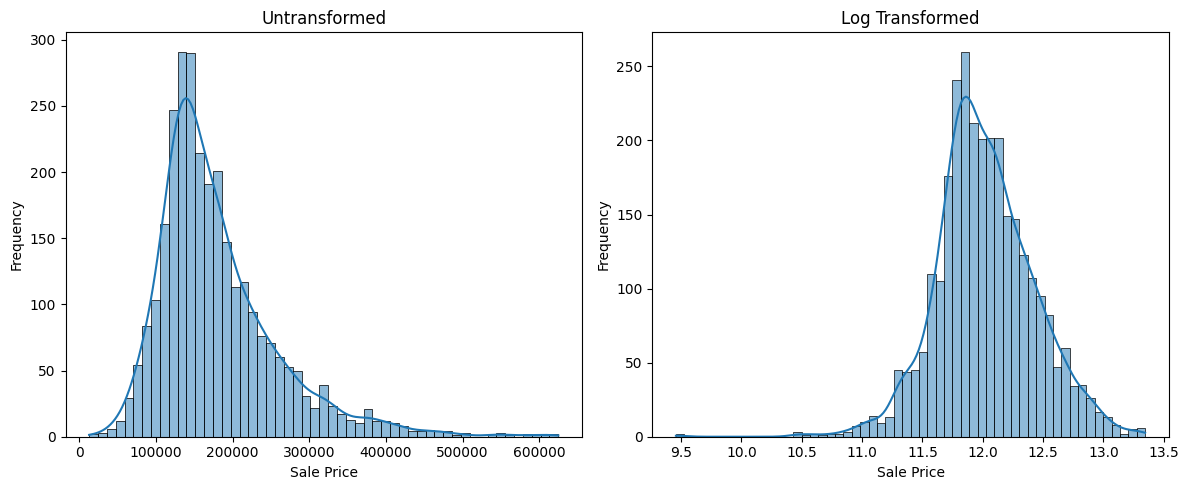

In [7]:
plt.figure(figsize=(12, 5))

# First histogram
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(x=df['SalePrice'], kde=True)
plt.title('Untransformed')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

# Second histogram
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(x = df['SalePrice'].map(np.log), kde=True)
plt.title('Log Transformed')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

plt.tight_layout() # Adjusts subplot params for a tight layout
plt.show()

--- Running Cross-Validation on Training Data ---
Cross-validated R-squared (mean ± std): 0.8905 ± 0.0171
Cross-validated Mean Squared Error (mean ± std): 0.0180 ± 0.0042

Intercept: 12.0180

Standardized Coefficients (Betas) from full data fit (using forward selection):
	Lot Area             :	    0.02
	Overall Qual         :	    0.12
	Overall Cond         :	    0.06
	Year Built           :	    0.08
	Year Remod/Add       :	    0.02
	BsmtFin SF 1         :	    0.02
	Bsmt Unf SF          :	   -0.02
	Total Bsmt SF        :	    0.07
	Gr Liv Area          :	    0.13
	Fireplaces           :	    0.02
	Garage Cars          :	    0.02
	Garage Area          :	    0.02
	Enclosed Porch       :	    0.01
	Yr Sold              :	   -0.01
	MS Zoning_RL         :	    0.02
	Lot Shape_Reg        :	   -0.01
	Bldg Type_1Fam       :	    0.02
	Heating QC_Ex        :	    0.02
	Sale Condition_Normal:	    0.01
	Foundation_PConc     :	    0.02

--- Running Final Evaluation on Unseen Test Data ---
Final Test R-s

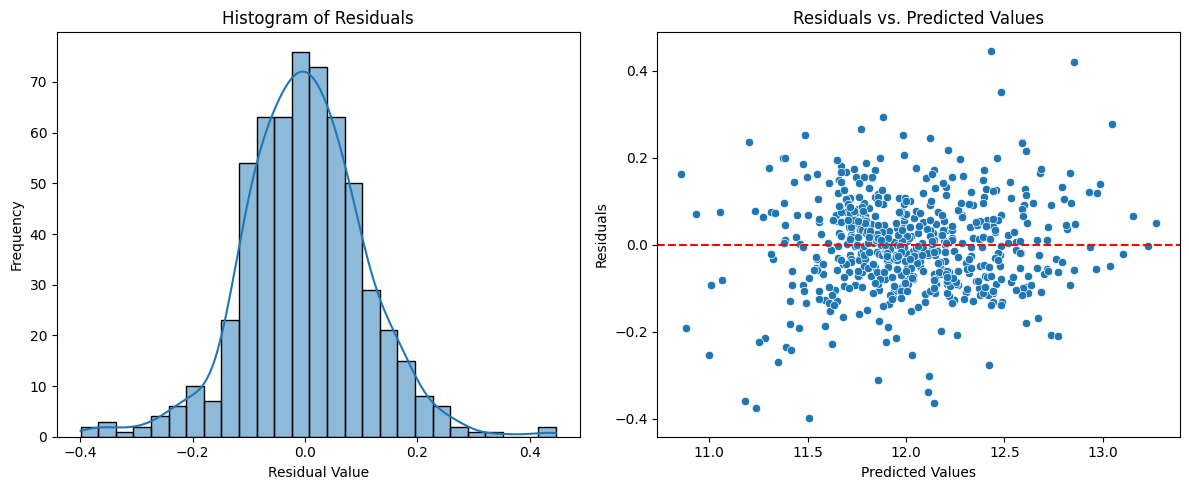

In [8]:
# define features and outcome
X = df.drop(columns=['SalePrice'])
ylog = df['SalePrice'].map(np.log)   # Note the log converison here

modeling_results = run_modeling_workflow(X, ylog, test_size=0.2, random_state=42)

### Add Polynomials to Model Non-Linear Features

In standard linear regression, the model assumes a strict, straight-line relationship between your input features and your target variable. However, our data sometimes clearly follows a non-linear (curved in some way) patther.

To capture curves, we can add squared features ($X^2$) that will allow the regression line to bend. Depending on the sign and weight of the coefficient, this curve can bend upwards (approximating accelerating/exponential growth or a U-shape) or downwards (capturing diminishing returns or an inverted U-shape).

By introducing these polynomial terms, we transform a simple model (straight lines only) into a much more flexible one (can accounts for curves in the data). Here is a brief approach on how and why to use them:

1. It is Still "Linear" Regression: Even though you are modeling a curve, the algorithm itself is still considered *Multiple Linear Regression*. This is because the model is linear in its **parameters** (the coefficients/weights). You are simply treating the squared term as a brand-new, independent feature.
Example Equation: $Y = \beta_0 + \beta_1(X) + \beta_2(X^2)$

2. Adding More Bends (Higher Degrees): While squared terms (degree 2) allow for exactly one bend (a parabola), you can add cubic terms ($X^3$, degree 3) to allow for two bends. This is particularly useful for modeling "S-curves," where growth starts slow, accelerates, and then levels off.

3. Some cautions to keep in mind:
* If you include a squared term ($X^2$) in your model, you should almost always include the base linear term ($X$) as well, even if its individual p-value doesn't seem significant. This anchors the curve correctly. We get to see if the curve is significant while controlling for the straight line version of the feature.
* Beware of Overfitting: It is tempting to add $X^3$, $X^4$, or $X^5$ to make the line fit your training data perfectly. However, higher-degree polynomials cause the regression line to become wildly "wiggly," leading to terrible predictions on unseen data. Rarely go above a degree of 2 or 3.
* Watch out for Multicollinearity: A base feature ($X$) and its square ($X^2$) are often highly correlated, which can confuse the model's coefficients. You can fix this by *centering* or *standardizing* your data (subtracting the mean and dividing by the standard deviation) before squaring it. This type of multicolinearity is sometimes called structural multicollinearity and it is NOT fixed by using the standard scaler in the pipeline. You must standardize when creating the polynomial. If you do not do this, your R2 and mse will be fine when running OLS, but your p-values will not. So you won't be able to tell if your polynomials are significantly adding to the model.

### Some Examples of Potential Polynomials for Ames

#### 1. `Overall Qual`
* **The Logic:** In a standard linear model, the jump from a Quality 4 to 5 adds the exact same dollar amount as the jump from Quality 9 to 10. But in real estate, ultra-luxury finishes command an exponential premium.
* **The Polynomial:** Adding `Overall Qual ** 2`.
* **What We Might See:** Both the linear and squared terms will likely be positive. The model will draw an upward-curving "hockey stick" line, proving that a 1-point increase at the high end of the scale is worth tens of thousands of dollars more than a 1-point increase at the low end.

### 2. `Bedroom AbvGr`
* **The Logic:** As we discussed with the negative coefficient, adding bedrooms while holding square footage constant means smaller rooms. But is the penalty linear? Going from 2 to 3 bedrooms in a 1,500 sq ft house is normal. Going from 5 to 6 bedrooms in that same house means you are living in a bizarre labyrinth of closets.
* **The Polynomial:** Adding `Bedroom AbvGr ** 2`.
* **What We Might See:** An inverted U-shape or a sharply steepening downward curve. The penalty for cramming one extra bedroom into a house gets exponentially worse the more bedrooms you add.

### 3. `Garage Area` Diminishing Returns
* **The Logic:** Going from a 0-car garage to a 2-car garage adds immense value to a home. Going from a 2-car to a 3-car garage is a nice luxury. But going from a 4-car to a 6-car garage adds very little extra value because almost no normal homebuyer needs that much space—unless they are a massive car collector.
* **The Polynomial:** Adding `Garage Area ** 2`.
* **What We Might See:** The linear term (`Garage Area`) will be positive, but the squared term (`Garage Area ** 2`) will be **negative**. This is the classic mathematical signature of "diminishing returns." The curve goes up, but it flattens out as the garage gets massive.



In [15]:
# Let's run a simple model to get a sense of how
# the polynomials might behave as features

import statsmodels.api as sm

# do initial standardization of polynomials
linear_features = ['Overall Qual', 'Bedroom AbvGr', 'Garage Area']
scaler = StandardScaler()
df_scaled_linear = scaler.fit_transform(df[linear_features])

# Convert back to a temp dataframe for easy squaring
temp_df = pd.DataFrame(df_scaled_linear, columns=linear_features, index=df.index)

# Create the squares from the ALREADY scaled versions
for col in linear_features:
    df[f'{col}_Sqr'] = temp_df[col] ** 2

reduced_features_plus_nonlinear =[
    'Overall Qual',
    'Bedroom AbvGr',
    'Garage Area',
    'Overall_Quality_Sqr',
    'Bedroom_AbvGr_Sqr',
    'Garage_Area_Sqr']

X = df[reduced_features_plus_nonlinear]
y = df['SalePrice'].map(np.log)

# --- Direct model training without feature selection to use all 6 features ---

# 1. Train-test split (using the same parameters as in run_modeling_workflow for consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4
)

# Add a constant to the independent variables for statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 2. Create and fit the OLS model using statsmodels
model_sm = sm.OLS(y_train, X_train_sm)
results_sm = model_sm.fit()

# 3. Print the summary which includes coefficients, p-values, R-squared, etc.
print(results_sm.summary())

# 4. Evaluate on test data using the statsmodels results to predict
test_predictions = results_sm.predict(X_test_sm)
final_r2 = r2_score(y_test, test_predictions)
final_mse = mean_squared_error(y_test, test_predictions)

print(f"\nFinal Test R-squared (all features): {final_r2:.4f}")
print(f"Final Test MSE (all features):       {final_mse:.4f}")

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     1167.
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:16:37   Log-Likelihood:                 401.20
No. Observations:                2340   AIC:                            -788.4
Df Residuals:                    2333   BIC:                            -748.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  10.4908    

There is some evidence here that the Garage Area Squared may contribute. The others show no evidence of contributing. Let's include all three with the features identified by our earlier model and see if the polynomials contribute anything beyond the others.  

--- Running Cross-Validation on Training Data ---
Cross-validated R-squared (mean ± std): 0.8886 ± 0.0137
Cross-validated Mean Squared Error (mean ± std): 0.0185 ± 0.0019

Intercept: 12.0221

Standardized Coefficients (Betas) from full data fit (using forward selection):
	Lot Area      :	    0.03
	Overall Qual  :	    0.13
	Overall Cond  :	    0.06
	Year Built    :	    0.11
	BsmtFin SF 1  :	    0.05
	Total Bsmt SF :	    0.05
	Gr Liv Area   :	    0.14
	Garage Area   :	    0.03
	Bldg Type_1Fam:	    0.02
	Heating QC_Ex :	    0.02

--- Running Final Evaluation on Unseen Test Data ---
Final Test R-squared: 0.9043
Final Test MSE:       0.0152


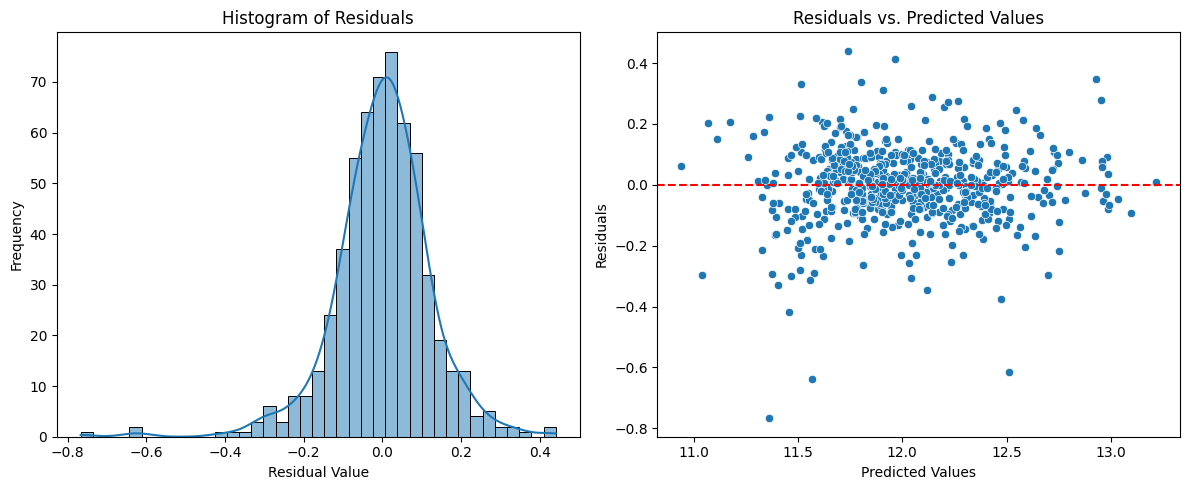

In [10]:
reduced_features_plus_nonlinear =[
    'Lot Area',
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Year Remod/Add',
    'BsmtFin SF 1',
    'Total Bsmt SF',
    'Gr Liv Area',
    'Bedroom AbvGr',
    'Garage Area',
    'Wood Deck SF',
    'Yr Sold',
    'garage_attached',
    'Bldg Type_1Fam',
    'Roof Style_Gable',
    'Exter Qual_TA',
    'Heating QC_Ex',
    'Foundation_PConc',
    'Overall_Quality_Sqr',
    'Bedroom_AbvGr_Sqr',
    'Garage_Area_Sqr']

X = df[reduced_features_plus_nonlinear]
y = df['SalePrice'].map(np.log)

modeling_results = run_modeling_workflow(X, ylog, test_size=0.2, random_state=4)

In this case, forward selection did not "choose" any of the polynomials. The model gets to 90% accuracy without them.

### Multi-Colinearity

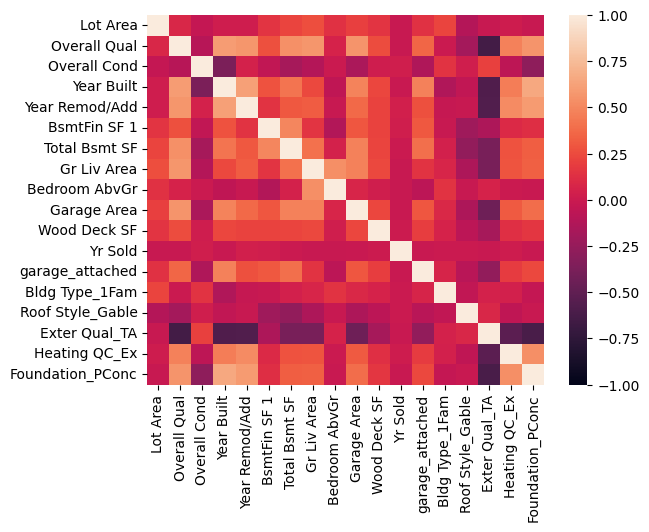

In [11]:
reduced_features = [
    'Lot Area',
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Year Remod/Add',
    'BsmtFin SF 1',
    'Total Bsmt SF',
    'Gr Liv Area',
    'Bedroom AbvGr',
    'Garage Area',
    'Wood Deck SF',
    'Yr Sold',
    'garage_attached',
    'Bldg Type_1Fam',
    'Roof Style_Gable',
    'Exter Qual_TA',
    'Heating QC_Ex',
    'Foundation_PConc']

sns.heatmap(df[reduced_features].corr(), vmin=-1, vmax=1)
plt.show()

In [16]:
# Calculate the correlation matrix
corr_matrix = df[reduced_features].corr()

# Unstack the correlation matrix to easily filter
stacked_corr = corr_matrix.stack()

# Filter for correlations above .7 in absolute value and exclude self-correlations
high_corr = stacked_corr[(abs(stacked_corr) > 0.7) & (stacked_corr != 1)]

# Sort for better readability
high_corr = high_corr.sort_values(ascending=False)

print("Features with absolute correlation > 0.7:")
if not high_corr.empty:
  # Print each pair, avoiding duplicates (e.g., A-B and B-A)
  printed_pairs = set()
  for (feature1, feature2), correlation in high_corr.items():
    # Ensure consistent order for pairs to avoid printing (A,B) and then (B,A)
    if (feature2, feature1) not in printed_pairs:
      print(f"  {feature1} - {feature2}: {correlation:.4f}")
      printed_pairs.add((feature1, feature2))
else:
  print("  No correlations above 0.7 found (excluding self-correlation).")

Features with absolute correlation > 0.7:
  No correlations above 0.7 found (excluding self-correlation).


So, if we only look at the features selected by forward selection, we do not see strong evidence of multi-colinearity. Consequently, we should be less concerned that our coefficients are distorted.

However, we might be concerned that multi-colinearity may have affected the forward selection process to begin with. Let's check out the correlations among all of the features.

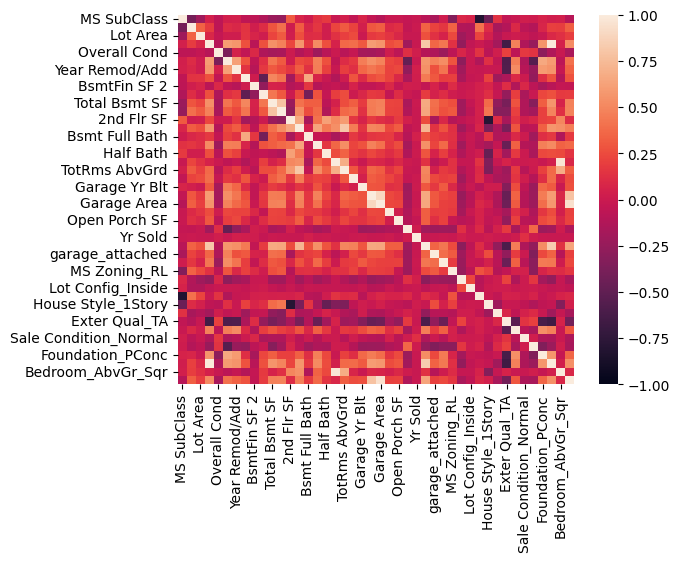

In [13]:
sns.heatmap(df.corr(), vmin=-1, vmax=1)
plt.show()

In [14]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Unstack the correlation matrix to easily filter
stacked_corr = corr_matrix.stack()

# Filter for correlations above .7 in absolute value and exclude self-correlations
high_corr = stacked_corr[(abs(stacked_corr) > 0.7) & (stacked_corr != 1)]

# Sort for better readability
high_corr = high_corr.sort_values(ascending=False)

print("Features with absolute correlation > 0.7:")
if not high_corr.empty:
  # Print each pair, avoiding duplicates (e.g., A-B and B-A)
  printed_pairs = set()
  for (feature1, feature2), correlation in high_corr.items():
    # Ensure consistent order for pairs to avoid printing (A,B) and then (B,A)
    if (feature2, feature1) not in printed_pairs:
      print(f"  {feature1} - {feature2}: {correlation:.4f}")
      printed_pairs.add((feature1, feature2))
else:
  print("No correlations above 0.7 found (excluding self-correlation).")

Features with absolute correlation > 0.7:
  Overall Qual - Overall_Quality_Sqr: 0.9875
  Bedroom AbvGr - Bedroom_AbvGr_Sqr: 0.9653
  Garage Area - Garage_Area_Sqr: 0.9399
  Garage Area - Garage Cars: 0.8921
  Overall_Quality_Sqr - SalePrice: 0.8324
  Gr Liv Area - TotRms AbvGrd: 0.8091
  SalePrice - Overall Qual: 0.8052
  Garage_Area_Sqr - Garage Cars: 0.7845
  Total Bsmt SF - 1st Flr SF: 0.7839
  Gr Liv Area - SalePrice: 0.7195
  House Style_1Story - 2nd Flr SF: -0.7922
  MS SubClass - Bldg Type_1Fam: -0.8154
